In [ ]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import seaborn as sns
from random import randint
from itertools import *
import scipy.interpolate as itp
from multiprocessing import Pool, Process

sys.path.append('/home/nishant/lab/MFB/scripts')
sys.path.append('/home/nishant/lab/MFB/steps')
sys.path.append('/home/nishant/lab/scripts')
from analysis import *
from peaks import *
from misc import *

## MCell analysis

In [11]:
dataPath = "/media/nishant/4tb/output/MFB/control/"
resultPath = "/home/nishant/lab/MFB/results/control/"

#dirs = [a for a in getDirs(resultPath, sstr='nVDCC') if "ISI_50" in a]
dirs = [a for a in getDirs(resultPath, sstr='nVDCC') if "nVDCC_" in a]

tempdirs = np.array(dirs)
for i,d in enumerate(tempdirs):
    print(i, d)

0 nVDCC_12_dVDCC_160_nAZ_27_RRP_5_ISI_20_nAP_10


### Averaging Calcium Data

In [4]:
fname = "ca.dat" 
for d in tq(tempdirs[:], desc=f'AVG ({fname}):'):
    try:
        avg_dat(dataPath, resultPath, d, fname, cores=35)
        CaConc(resultPath, d)
        #print(d)
    except:
        print(f'Error in {d}')

nVDCC_12_dVDCC_160_nAZ_27_RRP_5_ISI_20_nAP_10 : Done!



In [ ]:
fname = "ca.dat" 
jobInfo = list(product([dataPath], [resultPath], tempdirs[:], [fname]))

p = Pool(19)
p.starmap(avg_dat, jobInfo)
p.close()

### Generate AZ Calcium Concentration

In [ ]:
#CaConc(resultPath, tempdirs[3])
arg = list(product([resultPath], tempdirs[:]))
p = Pool(1)
p.starmap(CaConc, arg)
p.close()

## Plot MCell data

In [ ]:
#tempdirs = ['nVDCC_9_dVDCC_120_nAZ_7']
def plotCa(dir):
    CaGlobal = np.genfromtxt(os.path.join(resultPath,dir,'ca.dat'), unpack=True)
    CaAZ = np.genfromtxt(os.path.join(resultPath,dir,'CaConc.dat'), unpack=True)

    f, ax = plt.subplots(2, sharex=True, figsize=(15,8))
    f.subplots_adjust(hspace=0.0)

    ax[0].plot(CaGlobal[0]*1000, CaGlobal[1]*2.024e-4)
    ax[0].set_ylabel('Global Ca ($\mu$M)')
    ax[0].set_title(dir)

    for i in range(1,6):#len(CaAZ)+1):
        ax[1].plot(CaAZ[0]*1000+6*(i-1), CaAZ[i], label="AZ_{:d}".format(i))

    #ax[1].set_xlim(2, 3)
    ax[1].set_ylabel("$[Ca]$ ($\mu$M)")
    ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2)
    #ax[1].set_ylim(0,0.3)
    plt.show()
    
for dir in tempdirs[-1:]:
    plotCa(dir)

## AZ simulation in STEPS

In [5]:
from MFB_model import *
mdl, sim, r = get_MFB_model()

## Testing a single trail with STEPS

In [ ]:
CaFile = resultPath + 'nVDCC_8_dVDCC_100_nAZ_28/CaConc.dat'
CaData = np.genfromtxt(CaFile, unpack=True)

T = np.arange(CaData[0][0], CaData[0][-1], 1e-5)
CaInterp = itp.interp1d(CaData[0], CaData[1])
CaInterpData = CaInterp(T)

resCa, resAZ, vesRel = simAZ(T, CaInterpData, sim, r)

nFig = 3
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
figure.subplots_adjust(hspace=0.1)
labelfontsize = 13

ax[0].plot(T, resCa/cytVolVal*1.66*1e-3, label='Ca')
ax[0].set_ylabel(r'Ca ($\mu M$)', fontsize=labelfontsize)

for mol in azMolName[:18]:
    i = azMolName.index(mol)
    ax[1].plot(T, resAZ[:,i], label=mol)
ax[1].set_ylabel('AZ states (num)', fontsize=labelfontsize)
ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2)

vesRelSync  = np.sum(vesRel[:,:3], axis=1)
vesRelAsync = np.sum(vesRel[:,3:-1], axis=1)
vesRelSpont = vesRel[:,-1]
vesRelTot   = np.sum(vesRel, axis=1)

ax[2].plot(T, vesRelSync, label='sync')
ax[2].plot(T, vesRelAsync, label='async')
ax[2].plot(T, vesRelSpont, label='spont')
ax[2].plot(T, vesRelTot, label='total')
    
ax[2].set_ylabel('Vesicles released', fontsize=labelfontsize)
ax[2].legend()

peaks = detect_peaks(vesRelTot, edge='rising', show=False)
ax[2].plot(T[peaks], vesRelTot[peaks], '+', mfc=None, mec='r', mew=2, ms=15)
#print(T[peaks])

plt.show()

In [6]:
def runAZTrials(CaData, RRP):
    vesData = {}

    resAZ, vesRel = simAZ(CaData[0], CaData[1], sim, r, RRP=RRP)
    vesRelSync  = np.sum(vesRel[:,:3], axis=1)
    vesRelAsync = np.sum(vesRel[:,3:-2], axis=1)
    vesRelSpont  = vesRel[:,-1]

    vesRelTot = np.sum(vesRel, axis=1)
    #print(vesRelSync, vesRelAsync, vesRelSpont)

    pksSync = detect_peaks(vesRelSync, edge='rising', show=False)
    pksAsync = detect_peaks(vesRelAsync, edge='rising', show=False)
    pksSpont = detect_peaks(vesRelSpont, edge='rising', show=False)

    vesData.update({'sync' : list(CaData[0,pksSync])})
    vesData.update({'async': list(CaData[0,pksAsync])})
    vesData.update({'spont': list(CaData[0,pksSpont])})

    return vesData, resAZ

In [ ]:
def getVesRel(dir, RRP, resultPath, fname='CaConc.dat', trials=2000, pools=False):
    nAZ = int(getSimInfo(dir, 'nAZ'))
    
    CaFile = os.path.join(resultPath, dir, fname)
    CaData = np.genfromtxt(CaFile, unpack=True) # in uM
    
    if pools:
        p = Pool(pools)
    else:
        p = Pool()
        
    vesData = {}
    desc = str([int(a) for a in re.findall(r'\d+', dir)[:-1]])
    for iCa in tq(range(1,nAZ+1), desc=desc):
        info = product([CaData[(0,iCa),:]], [RRP]*trials)
        data = np.array(p.starmap(runAZTrials, info))
        
        vesSync  = [a['sync'] for a in data[:,0]]
        vesAsync = [a['async'] for a in data[:,0]]
        vesSpont = [a['spont'] for a in data[:,0]]
        vesData.update({f'AZ{iCa}': {'sync': vesSync, 'async':vesAsync, 'spont':vesSpont}})
        
        resAZ = data[:,1]
        AZstates = np.mean(resAZ, axis=0)
        fAZ = os.path.join(resultPath, dir, f'AZ_{iCa}.dat')
        AZdata = np.hstack((np.array([CaData[0]]).T, AZstates))
        # np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.4f']*18, delimiter="\t")
        
    #print(vesData)
    p.close()
    return vesData

In [ ]:
for d in tq(tempdirs[:1]):
    try:
        nVDCC, dVDCC, nAZ, RRP = [int(getSimInfo(d, key)) for key in ['nVDCC', 'dVDCC', 'nAZ', 'RRP']]
        #print(nVDCC, dVDCC, nAZ, RRP)
        
        vesData = getVesRel(d, RRP=RRP, resultPath=resultPath, trials=2000, pools=35)
        with open(os.path.join(resultPath, d, 'vesData.dat'),"wb") as outfile:
            pk.dump(vesData, outfile)
            
        relStat(d, resultPath, resample=1000)
    except:
        print(f'Error in {d}')

/home/nishant/.local/lib/python3.6/site-packages/ipykernel_launcher.py:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  app.launch_new_instance()


[[2.39210500e-01 9.45404357e-03 2.79364500e-01 1.20512402e-02
  1.00000000e+00 0.00000000e+00]
 [5.07356000e-01 1.11096698e-02 6.88957500e-01 1.79650061e-02
  2.12424913e+00 9.54555996e-02]
 [6.89806000e-01 1.00994735e-02 1.13843550e+00 2.27609773e-02
  2.88824167e+00 1.23163810e-01]
 [7.85326000e-01 9.18372060e-03 1.55467500e+00 2.77158686e-02
  3.28819605e+00 1.37367467e-01]
 [8.79703500e-01 7.28318871e-03 2.06205150e+00 3.08743275e-02
  3.68331643e+00 1.49716435e-01]
 [9.20381000e-01 6.14600187e-03 2.44992550e+00 3.44163798e-02
  3.85364629e+00 1.55902920e-01]
 [9.51470500e-01 4.75572074e-03 2.91670350e+00 3.71641203e-02
  3.98381617e+00 1.60131737e-01]
 [9.70481000e-01 3.90379802e-03 3.30684500e+00 3.92389472e-02
  4.06334213e+00 1.61108611e-01]
 [9.74548000e-01 3.44350054e-03 3.59887450e+00 4.20383813e-02
  4.08037037e+00 1.61612294e-01]
 [9.81193000e-01 3.06075987e-03 3.88662550e+00 4.47143713e-02
  4.10823843e+00 1.63710492e-01]]



## Get Vesicle Release Statistics

In [ ]:
for dir in tqdmn(tempdirs[:1]):
    #relStat(d, resultPath, resample=100)
    try:
        relStat(dir, resultPath, resample=1000)
    except:
        print(f'Error in {dir}')

In [ ]:
### parallely
jobInfo = list(product(tempdirs[:], [resultPath], [1000]))
#print(info)

p = Pool(20)
p.starmap(relStat, jobInfo)
p.close()

# Calcium and Buffer Extent

## Get Ca count in each box

In [38]:
def getCaCount(simdir, resultPath, step=0.05):
    """
    step: individual cell size in um
    timepoint in nano second
    """
    ISI = int(getSimInfo(simdir, 'ISI'))*1000 # in number of steps
    nstim = int(getSimInfo(simdir, 'nAP'))
    cbMolName = ['H0M0', 'H0M1', 'H0M2', 
                 'H1M0', 'H1M1', 'H1M2', 
                 'H2M0', 'H2M1', 'H2M2']
        
    xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

    ### Generate grid to store calcium ion count
    # caGrid := [nstim, nx, ny, nz]
    # cbmolGrid := [nstim, nx, ny, nz]
    # cbGrid := {cbmol: cbmolGrid}
    caGrid = np.zeros((nstim+1, int(np.ceil((xlim[1] - xlim[0])/step)), int(np.ceil((ylim[1] - ylim[0])/step)),
                      int(np.ceil((zlim[1] - zlim[0])/step))))
    
    cbGrid = {}
    for cbmol in cbMolName:
        cbGrid.update({cbmol: np.zeros(caGrid.shape)})
    #print(cbGrid)
    
    nseeds = len([a for a in os.listdir(os.path.join(dataPath, simdir))
                  if os.path.isdir(os.path.join(dataPath, simdir, a))])
    #print(nseeds)
    
    nseeds = 1
    #nstim = 1
    for seed in tq(range(1, nseeds+1), desc='seeds:'):
        # get timepoints with peak Ca
        peaktps = np.zeros(nstim+1, dtype=int)
        caids = np.zeros(nstim+1).tolist()
        cbids = np.zeros(nstim+1).tolist()
        for ns in range(nstim+1):#, desc='Peak Ca Timpepoints'):
            if not ns:
                tp = 1
                data = np.genfromtxt(os.path.join(dataPath, simdir, f's_{seed:05}', f'viz/mfb.ascii.{tp:06}.dat'), 
                                        usecols=(0), dtype=str)
                
                caids[ns] = np.where(data == 'Ca')[0]
                cbids[ns] = {cbmol: np.where(data == 'cb'+cbmol)[0] for cbmol in cbMolName}
                peaktps[ns] = tp
            
            else:
                for tp in range(2250+ISI*(ns-1), 2500+ISI*(ns-1)+1, 50):
                    data = np.genfromtxt(os.path.join(dataPath, simdir, f's_{seed:05}', f'viz/mfb.ascii.{tp:06}.dat'), 
                                            usecols=(0), dtype=str)

                    caidTemp = np.where(data == 'Ca')[0]
                    cbidTemp = {cbmol: np.where(data == 'cb'+cbmol)[0] for cbmol in cbMolName}
                    #print(cbidTemp)

                    countCa = np.count_nonzero(data == 'Ca')
                    #print(caidTemp, len(caidTemp), countCa)
                    if countCa > peaktps[ns]: 
                        peaktps[ns] = tp
                        caids[ns] = caidTemp
                        cbids[ns] = cbidTemp
        print(peaktps)
        
        
        # get CaData
        for ns in range(nstim+1):#, desc='caGrid'):
            tp = peaktps[ns]
            data = np.genfromtxt(os.path.join(dataPath, simdir, f's_{seed:05}', f'viz/mfb.ascii.{tp:06}.dat'), 
                                 usecols=(2,3,4))
            cadata = data[caids[ns]]
            cbdata = {cbmol: data[cbids[ns][cbmol]] for cbmol in cbMolName}
            #print(cbdata)

            gridLim = np.array([xlim[0], ylim[0], zlim[0]])
            caboxidx = np.array(np.floor((cadata - gridLim)/step), dtype='int')
            cbboxidx = {cbmol: np.array(np.floor((cbdata[cbmol] - gridLim)/step), dtype='int') for cbmol in cbMolName}

            for xid, yid, zid in caboxidx:
                caGrid[ns][xid][yid][zid] += 1
                
            for cbmol in cbMolName:
                for xid, yid, zid in cbboxidx[cbmol]:
                    cbGrid[cbmol][ns][xid][yid][zid] += 1
                
    
    caGrid *= 0.0166*np.power(step, -3)/nseeds # 0.0166*n/s^3 gives the concentration in uM
    for cbmol in cbMolName:
        cbGrid[cbmol] *= 0.0166*np.power(step, -3)/nseeds
        
        
    if not os.path.exists(os.path.join(resultPath,simdir)):
        os.makedirs(os.path.join(resultPath,simdir))

    with open(os.path.join(resultPath, simdir, f'caGrid.dat'),"wb") as outfile:
        pk.dump(caGrid, outfile)
        
    with open(os.path.join(resultPath, simdir, f'cbGrid.dat'),"wb") as outfile:
        pk.dump(caGrid, outfile)
        
    return caGrid, cbGrid

    
caGrid, cbGrid = getCaCount(tempdirs[-2], resultPath)

[     1   2450  22250  42250  62250  82250 102250 122250 142250 162250
 182250]


In [ ]:
def getCaCountDel(simdir, resultPath, dataPath):
    ISI = int(getSimInfo(simdir, 'ISI'))*1000 # in number of steps
    nstim = int(getSimInfo(simdir, 'nAP'))
    
    nseeds = len([a for a in os.listdir(os.path.join(dataPath, simdir))
                  if os.path.isdir(os.path.join(dataPath, simdir, a))])
    
    seed = 1
    #nstim = 4
    peaktps = np.zeros(nstim+1, dtype=int)
    for ns in tq(range(nstim)):
        for tp in range(2250+ISI*ns, 2500+ISI*ns+1, 50):
            data = np.genfromtxt(os.path.join(dataPath, simdir, f's_{seed:05}', f'viz/mfb.ascii.{tp:06}.dat'), 
                                    usecols=(0), dtype=str)

            countCa = np.count_nonzero(data == 'Ca')
            if countCa > peaktps[ns]: 
                peaktps[ns] = tp

    print(peaktps)
    
    
    #peaktps = [2450, 22250, 42250, 62250, 82250, 102250, 122250, 142250, 162250, 182250]
    for seed in tq(range(1, nseeds+1), desc='seeds:'):
        for ns in tq(range(nstim)):
            for tp in range(2250+ISI*ns, 2500+ISI*ns+1, 50):
                if tp not in peaktps:
                    delf = os.path.join(dataPath, simdir, f's_{seed:05}', f'viz/mfb.ascii.{tp:06}.dat')
                    os.remove(delf)
                    print(delf)
    
getCaCountDel(tempdirs[0], resultPath, dataPath)

In [ ]:
plt.subplots(figsize=(8,4))
#ax = sns.heatmap(caGrid, vmax=maxCa, vmin=0, xticklabels=xlim, yticklabels=ylim)
ax = sns.heatmap(caGrid[1,:,:,0].T)
#ax.text(2, 2, f'{t/1000} ms', c='w', size=25)
#ax.set_xticks(range(0,100,caGrid.shape[1]))
#ax.set_yticks(range(0,100,caGrid.shape[2]))
ax.invert_yaxis()

In [ ]:
for d in tqdmn(dirs[:1]):
    try:
        xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
        maxCa = 0
        for t in range(0,5001,100):
            with open(os.path.join(resultPath, d, f'caGrid_{t:05}.dat'), "rb") as infile:
                caGrid = pk.load(infile)
            caGrid *= 0.83 # conversion from number of Ca ions to conc. in uM
            curCaMax = np.max(caGrid)
            if curCaMax > maxCa:
                maxCa = curCaMax

        for t in tqdmn(range(0,5001,100), desc=d):
            with open(os.path.join(resultPath, d, f'caGrid_{t:05}.dat'), "rb") as infile:
                caGrid = pk.load(infile)
            caGrid *= 13.28 # conversion from number of Ca ions to conc. in uM (vol = (50nm)^3)

            ### Plot the heatmap of the calcium
            plt.subplots(figsize=(8,4))
            ax = sns.heatmap(caGrid, vmax=maxCa, vmin=0, xticklabels=xlim, yticklabels=ylim)
            ax.text(2, 2, f'{t/1000} ms', c='w', size=25)
            ax.set_xticks(range(0,100,caGrid.shape[1]))
            ax.set_yticks(range(0,100,caGrid.shape[0]))
            ax.invert_yaxis()
            plt.savefig(os.path.join(resultPath, d, f'caGrid_{t:05}.png'), dpi=200, bbox_inches='tight', pad_inches=0.0, transparent=True)
            
    except:
        print(f'ERROR in {d}')

## EPSC calculations

[0.0000e+00 5.0000e-05 1.0000e-04 ... 2.2485e-01 2.2490e-01 2.2495e-01] (4500,)
(4500,) (4199,)


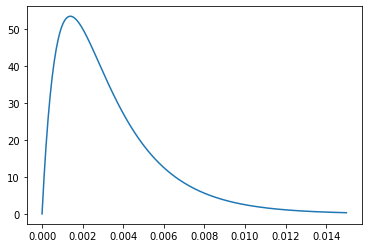

In [5]:
# qEPSC kernel
def dexp(x, a=146, b=407, c=1154):
    """
    fit values:
    a = 146
    b = 407
    c = 1154
    """
    return a*np.exp(-b*x)-a*np.exp(-c*x)


EPSCk_ = np.genfromtxt(os.path.join(resultPath, tempdirs[1], 'CaConc.dat'), usecols=(0), unpack=True)
avgEPSC = np.zeros(EPSCk_.shape[0] + 301)
tpoints = np.arange(0,EPSCk_[-1]+0.0151, 5e-5)

print(tpoints, tpoints.shape)
print(avgEPSC.shape, EPSCk_.shape)

EPSCk = dexp(EPSCk_[:301]) # 15 ms
plt.plot(tpoints[:301], EPSCk);

41 42


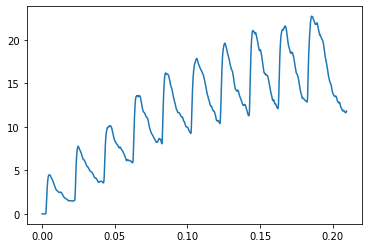

In [36]:
for dir in tempdirs[:1]:
    inf = os.path.join(resultPath, dir, 'vesData.dat')

    with open(inf, "rb") as infile:
        vesData = pk.load(infile)

    df = pd.io.json.json_normalize(vesData, sep='_')
    df = df.to_dict(orient='records')[0]
    
    emptyKeys = []
    for k,v in df.items():
        if all([not a for a in v]):
            emptyKeys.append(k)
            
    for e in emptyKeys:
        df.pop(e)
          
    # times of all the releases
    vTimes = np.sort(np.concatenate(np.concatenate(list(df.values())))) 
    #print(vTimes, vTimes.shape)
    
    EPSCk_ = np.genfromtxt(os.path.join(resultPath, tempdirs[1], 'CaConc.dat'), usecols=(0), unpack=True)
    avgEPSC = np.zeros(EPSCk_.shape[0] + 301)
    tpoints = np.arange(0,EPSCk_[-1]+0.0151, 5e-5)
    
    for vt in vTimes[:]:
        tid = int(vt/5e-5+1e-6)
        #print(vt, tid, tpoints[tid])
        avgEPSC[tid:tid+301] += EPSCk
        
    avgEPSC = avgEPSC/2000
    tpoints, avgEPSC = tpoints[:-310], avgEPSC[:-310]
    plt.plot(tpoints, avgEPSC)
    
    bins = np.arange(0, EPSCk_[-1], 0.005)
    n, bins = np.histogram(vTimes, bins)
    print(len(n), len(bins))
    
    fepsc = os.path.join(resultPath, dir, 'epsc.dat')
    #np.savetxt(fepsc, np.array([tpoints, avgEPSC]).T, fmt=['%0.5f']+['%0.3f'], delimiter="\t")

## Plotting Data

In [ ]:
nFig = 3
figure, ax = plt.subplots(nFig, figsize=(10, 3*nFig), sharex=True)
#figure.tight_layout()
figure.subplots_adjust(hspace=0.0, top=.95)

for d in tempdirs[1:].tolist()+tempdirs[:1].tolist():
    fname = os.path.join(resultPath, d, 'result_RRP_30.dat')
    relData = np.genfromtxt(fname, unpack=True)

    ax[0].plot(range(1,len(relData[0])+1), relData[0], 'o-', label=getSimInfo(d, 'ISI'))
    ax[0].set_ylabel('Pr')
    ax[0].legend(frameon=False)
    
    ax[1].plot(range(1,len(relData[0])+1), relData[0]/relData[0][0], 'o-', label=getSimInfo(d, 'ISI'))
    ax[1].set_ylabel('$Pr_n/Pr_1$')
    ax[1].legend(frameon=False)
    
    ax[2].plot(range(1,len(relData[0])+1), relData[2], 'o-', label=getSimInfo(d, 'ISI'))
    ax[2].set_ylabel('Releases per trial')
    ax[2].set_xlabel('Stimulus number')
    ax[2].legend(frameon=False)

figure.suptitle("nVDCC_5_dVDCC_100_nAZ_18")
figure.savefig('nVDCC_5_dVDCC_100_nAZ_18.eps', fmt='eps', dpi=300, transparent=True)

## Extra Stuff

In [51]:
from scipy.interpolate import interp1d
import os, sys
import numpy as np
import pickle as pk
from random import randint
from itertools import *
import scipy.interpolate as itp
from multiprocessing import Pool, Process

sys.path.append('/home/nishant/lab/MFB/scripts')
sys.path.append('/home/nishant/lab/MFB/steps')
sys.path.append('/home/nishant/lab/scripts')
from analysis import *
from peaks import *
from misc import *

dataPath = "/media/nishant/4tb/output/MFB/control/"
resultPath = "/home/nishant/lab/results/MFB/control/"
fname = "ca.dat" 
dirs = [a for a in getDirs(dataPath, sstr='nVDCC') if "ISI_20" in a]

### Ca Concentration Calculation
def _getConc(data, step=5):
    #sdata = savgol_filter(data[1], 51, 3)
    sdata = data[1]
    
    #plt.plot(data[0],sdata)
    #plt.ylim(0,0.2)
    
    c_tc = np.multiply(data[0],sdata)
    dt = step*(data[0][1]-data[0][0])

    c_out = []
    for i in range(0,len(data[0])-step-1,step):
        c_out.append((c_tc[i+step]-c_tc[i])/dt)

    return np.array(c_out)

fname = 'ca.dat'
dir = tempdirs[-1]
data = np.genfromtxt(os.path.join(dataPath,dir,'s_00001/dat',fname), unpack=True)
#data = np.genfromtxt(os.path.join(resultPath,dir,fname), unpack=True)
T, Ca = data[[0,2]]
TT = np.arange(T[0], T[-1], 1e-7)

print(TT.shape, T.shape)
interpf = interp1d(T, Ca, kind='cubic')
nCa = interpf(TT)
print(nCa.shape)

f, ax = plt.subplots(3, sharex=True, figsize=(20,10))
f.subplots_adjust(wspace=0.0, hspace=0.0)

ax[0].plot(T, Ca)
ax[0].plot(TT, nCa)
ax[1].plot(T[:-2], _getConc([T,Ca], step=1))
ax[2].plot(TT[:-2], _getConc([TT, nCa], step=1));

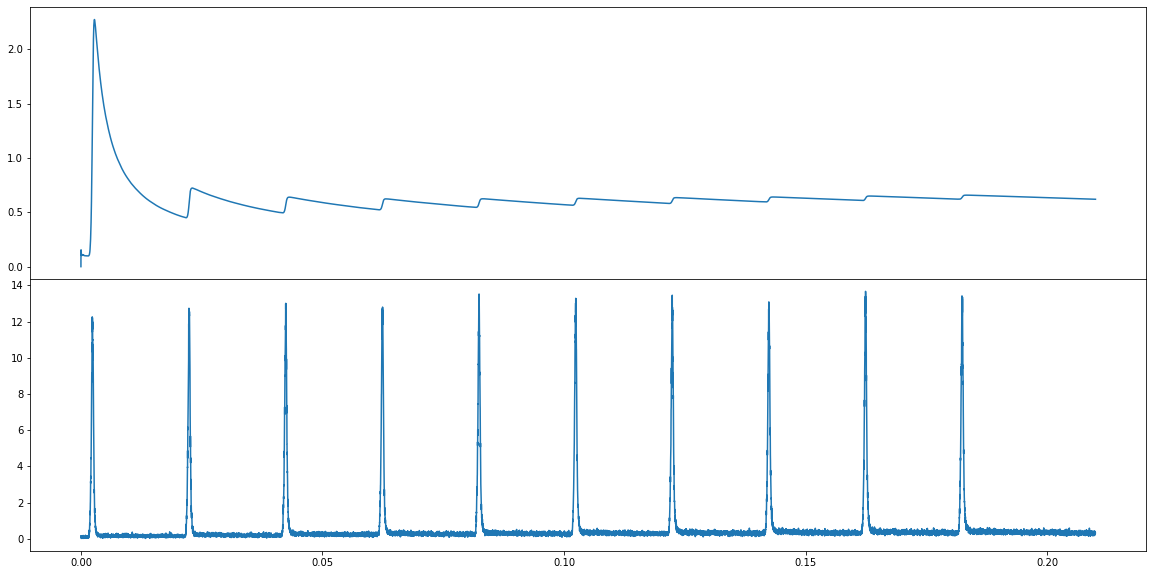

In [53]:
data = np.genfromtxt(os.path.join(resultPath,dir,fname), unpack=True)
T, Ca = data[[0,2]]

f, ax = plt.subplots(2, sharex=True, figsize=(20,10))
f.subplots_adjust(wspace=0.0, hspace=0.0)

ax[0].plot(T, Ca)
ax[1].plot(T[:-2], _getConc([T,Ca], step=1))
#ax[1].grid();

In [ ]:
resultPath = "/home/nishant/lab/MFB/results/control/"
dirs = [a for a in getDirs(dataPath, sstr='nVDCC') if "ISI_20" in a]

tempdirs = np.array(dirs)

for dir in tempdirs[1:2]:
    inf = os.path.join(resultPath, dir, 'vesData.dat')
    print(dir)
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)
        for k,v in vesData.items():
            print('\t', k, v)